In [5]:
import jax.numpy as jnp
import jax
from core.utils import *
from core.model import SparseHyperelasticityGP
from core.material_models import get_material
from core.datasetclass import BenchmarkDataset

In [6]:
from dolfinx import log, default_scalar_type
from dolfinx.fem.petsc import NonlinearProblem
import numpy as np
from dolfinx.io.gmsh import read_from_msh
import ufl
import gmsh
from mpi4py import MPI
from dolfinx import fem, mesh, plot

In [7]:
gmsh.initialize()
gdim = 2
model = gmsh.model.occ
L_x = 1.0
L_y = 1.0
R_hole = 0.1
mesh_size = 0.05
# 2. Create rectangle
rect = model.addRectangle(0.0, 0.0, 0.0, L_x, L_y)

# 3. Create circle
circle = model.addDisk(0.0, 0.0, 0.0, R_hole, R_hole)

# 4. Cut the hole
domain_with_hole, _ = model.cut([(gdim, rect)], [(gdim, circle)])
gmsh.model.occ.synchronize()

# 5. Physical group
gmsh.model.addPhysicalGroup(gdim, [rect], 1)
gmsh.model.setPhysicalName(gdim, 1, "domain")
gmsh.option.setNumber("Mesh.CharacteristicLengthMin", mesh_size)
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", mesh_size)
gmsh.model.mesh.generate(gdim)
# 6. Mesh generation
gmsh.model.mesh.generate(gdim)

# 7. Write to file
gmsh.write("mesh.msh")
gmsh.finalize()

# 8. Read into DOLFINx
mesh_ = read_from_msh("mesh.msh", MPI.COMM_WORLD, 0, gdim)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Ellipse)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 50%] Meshing curve 3 (Line)
Info    : [ 70%] Meshing curve 4 (Line)
Info    : [ 90%] Meshing curve 5 (Line)
Info    : Done meshing 1D (Wall 0.000851007s, CPU 0s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0141073s, CPU 0.008147s)
Info    : 521 nodes 1045 elements
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00898805s, CPU 0.008836s)
Info    : 521 nodes 1045 elements
Info    : Writing 'mesh.msh'...
Info    : Done writing 'mesh.msh'
Info    : Reading 'mesh.msh'...
Info    : 11 entities
Info    : 521 nodes
Info    : 960 elements
Info    : Done reading 'mesh.msh'


In [52]:
msh_data = read_from_msh("mesh_with_hole.msh", MPI.COMM_WORLD, 0, 2) 
domain = msh_data.mesh

node_coords = domain.geometry.x[:, :2]  # numpy array
num_nodes, gdim = node_coords.shape
# 3. Extract cell connectivity (triangles)
tdim = domain.topology.dim
domain.topology.create_connectivity(tdim, 0)
cells = domain.geometry.dofmap

np.savez("mesh/square_with_holes.npz", node_coords = node_coords, cells = cells)

Info    : Reading 'mesh_with_hole.msh'...
Info    : 13 entities
Info    : 1220 nodes
Info    : 2224 elements
Info    : Done reading 'mesh_with_hole.msh'


In [177]:
# Import some useful modules.
import jax
import jax.numpy as jnp
import os

# Import JAX-FEM specific modules.
from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import box_mesh_gmsh, get_meshio_cell_type, Mesh
import jax.random as jr 
jax.config.update("jax_enable_x64", True)

from core.utils import *
from core.model import SparseHyperelasticityGP
from core.material_models import get_material
from core.datasetclass import BenchmarkDataset

In [188]:

# Define constitutive relationship.
class HyperElasticity(Problem):
    def __init__(self, material_model_piola_stress, **kwargs) :
        super().__init__(**kwargs)
        self.material_model_piola_stress = material_model_piola_stress # should be function outputing piola stress [2x2 matrix]
    def custom_init(self):
        self.fe = self.fes[0]
    def get_surface_maps(self):
        def surface_map(u, x, load):
            return jnp.array([0., -load[0]])
        return [surface_map]
    def set_params(self, params):
        surface_params = params
        self.internal_vars_surfaces = [[surface_params]]
    def get_tensor_map(self):

        def first_PK_stress(u_grad):
            I = jnp.eye(self.dim)
            F = u_grad + I
            P = self.material_model_piola_stress(F)
            return P

        return first_PK_stress
    
# Specify mesh-related information (first-order hexahedron element).
mesh_data = jnp.load("/home/mmdiscovery/shared/mesh/square_with_holes.npz")
node_coords = mesh_data["node_coords"]
cells = mesh_data["cells"]
ele_type = 'TRI3'
cell_type = get_meshio_cell_type(ele_type)
data_dir = os.path.join('data')

mesh = Mesh(node_coords, cells)


# Define boundary locations.
def left(point):
    return jnp.isclose(point[0], 0., atol=1e-6)
def bottom(point):
    return jnp.isclose(point[1], 0., atol=1e-6)
def right(point):
    return jnp.isclose(point[0], 1., atol=1e-6)
def top(point):
    return jnp.isclose(point[1], 1.0, atol=1e-6)

zero_dbc = lambda point : 0
top_dbc = lambda point : 0.1
dirichlet_bc_info = [
    [bottom] * 2 , 
    [0, 1],
    [zero_dbc, zero_dbc]
                     ]
true_material_model = get_material("isihara")
true_piola_stress_func = lambda f : true_material_model.P(fto3x3(f))[:2, :2]


model_path = "/home/mmdiscovery/shared/saved_model/20260103T112935/" # Replace with the actual path to your saved model
with open(os.path.join(model_path, "best_params.npy"), "rb") as f:
    best_params = jnp.load(f, allow_pickle=True).item()

with open(os.path.join(model_path, "z_stacked.npy"), "rb") as f:
    Z_stacked = jnp.load(f, allow_pickle=True)
learned_gp = SparseHyperelasticityGP(best_params, Z_stacked)

pred_piola_stress_func = lambda f: learned_gp.piola_stress(fto3x3(f), key = None)[:2, :2]

# # Create an instance of the problem.
problem_true = HyperElasticity(mesh = mesh,
                          vec=2,
                          dim=2,
                          ele_type=ele_type,
                          dirichlet_bc_info=dirichlet_bc_info,
                          location_fns = [top],
                          material_model_piola_stress=true_piola_stress_func)

problem_pred = HyperElasticity(mesh = mesh,
                          vec=2,
                          dim=2,
                          ele_type=ele_type,
                          dirichlet_bc_info=dirichlet_bc_info,
                          location_fns = [top],
                          material_model_piola_stress=pred_piola_stress_func)
petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt", 
    "ksp_type": "gmres",
    "pc_type": "hypre",
    "ksp_rtol": 1e-9,  # Force higher accuracy in the linear solve
    "ksp_atol": 1e-12,
}
loads = jnp.linspace(0.1, 4.0, 10)
# Solve the defined problem.

# u_true = jnp.zeros_like(node_coords)

def solve_fem(problem, petsc_options, loads) :
    u = jnp.zeros_like(problem.mesh[0].points)
    for i, load in enumerate(loads):
        print("load step ", i, "= ", load)
        shape = (len(problem.boundary_inds_list[0]), problem.fes[0].num_face_quads, 1)
        problem.internal_vars_surfaces = [
            [
                jnp.full(fill_value=load, shape=shape),
            ]
        ]
        u = solver(problem, solver_options={'petsc_solver': petsc_options,
                                                'initial_guess': u})[0]
    return u

u_true = solve_fem(problem_true, petsc_options, loads)
main_key = jr.PRNGKey(42)
n_samples = 25
u_samples = []
for i in range(n_samples) :
    main_key, subkey = jr.split(main_key)
    # u_pred = jnp.zeros_like(node_coords)

    pred_piola_stress_func = lambda f: learned_gp.piola_stress(fto3x3(f), key = subkey)[:2, :2]
    problem_pred = HyperElasticity(mesh = mesh,
                            vec=2,
                            dim=2,
                            ele_type=ele_type,
                            dirichlet_bc_info=dirichlet_bc_info,
                            location_fns = [top],
                            material_model_piola_stress=pred_piola_stress_func)
    u_pred = solve_fem(problem_pred, petsc_options, loads)
    u_samples.append(u_pred)

[01-03 17:42:56][DEBUG] jax_fem: Computing shape function values, gradients, etc.


[01-03 17:42:56][DEBUG] jax_fem: ele_type = TRI3, quad_points.shape = (num_quads, dim) = (1, 2)
[01-03 17:42:56][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (3, 1, 2)
[01-03 17:42:56][DEBUG] jax_fem: Done pre-computations, took 0.014623403549194336 [s]
[01-03 17:42:56][INFO] jax_fem: Solving a problem with 2224 cells, 1220x2 = 2440 dofs.
[01-03 17:42:56][INFO] jax_fem: Element type is TRI3, using 1 quad points per element.
[01-03 17:42:56][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[01-03 17:42:56][DEBUG] jax_fem: ele_type = TRI3, quad_points.shape = (num_quads, dim) = (1, 2)
[01-03 17:42:56][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (3, 1, 2)
[01-03 17:42:56][DEBUG] jax_fem: Done pre-computations, took 0.0183260440826416 [s]
[01-03 17:42:56][INFO] jax_fem: Solving a problem with 2224 cells, 1220x2 = 2440 dofs.
[01-03 17:42:56][INFO] jax_fem: Element type is TRI3, using 1 quad points per element.
[0

load step  0 =  0.1


[01-03 17:42:59][DEBUG] jax_fem: Function split_and_compute_cell took 2.3716 seconds
[01-03 17:42:59][DEBUG] jax_fem: Creating sparse matrix with scipy...
[01-03 17:42:59][DEBUG] jax_fem: Before, l_2 res = 0.017023289562926803, relative l_2 res = 1.0
[01-03 17:42:59][DEBUG] jax_fem: Solving linear system...
[01-03 17:42:59][DEBUG] jax_fem: PETSc Solver - Solving linear system with ksp_type = gmres, pc = hypre
[01-03 17:42:59][DEBUG] jax_fem: PETSc Solver - Finished solving, linear solve res = 7.476494940455085e-06
[01-03 17:42:59][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[01-03 17:42:59][DEBUG] jax_fem: Function split_and_compute_cell took 0.0116 seconds
[01-03 17:42:59][DEBUG] jax_fem: Creating sparse matrix with scipy...
[01-03 17:42:59][DEBUG] jax_fem: l_2 res = 0.006123091486373476, relative l_2 res = 0.35968908733763777
[01-03 17:42:59][DEBUG] jax_fem: Solving linear system...
[01-03 17:42:59][DEBUG] jax_fem: PETSc Solver - Solving linear system with ksp_type =

load step  1 =  0.5333333333333333


...

load step  6 =  2.6999999999999997


[01-03 17:43:08][DEBUG] jax_fem: PETSc Solver - Finished solving, linear solve res = 1.6660385191919459e-07
[01-03 17:43:08][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[01-03 17:43:08][DEBUG] jax_fem: Function split_and_compute_cell took 0.0254 seconds
[01-03 17:43:08][DEBUG] jax_fem: Creating sparse matrix with scipy...
[01-03 17:43:08][DEBUG] jax_fem: l_2 res = 0.0013597217732597906, relative l_2 res = 0.018432510249324942
[01-03 17:43:08][DEBUG] jax_fem: Solving linear system...
[01-03 17:43:08][DEBUG] jax_fem: PETSc Solver - Solving linear system with ksp_type = gmres, pc = hypre
[01-03 17:43:08][DEBUG] jax_fem: PETSc Solver - Finished solving, linear solve res = 7.2399111682052175e-09
[01-03 17:43:08][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[01-03 17:43:09][DEBUG] jax_fem: Function split_and_compute_cell took 0.0199 seconds
[01-03 17:43:09][DEBUG] jax_fem: Creating sparse matrix with scipy...
[01-03 17:43:09][DEBUG] jax_fem: l_2 res = 1.09007

load step  7 =  3.1333333333333333


[01-03 17:43:09][DEBUG] jax_fem: PETSc Solver - Solving linear system with ksp_type = gmres, pc = hypre
[01-03 17:43:09][DEBUG] jax_fem: PETSc Solver - Finished solving, linear solve res = 5.570089969642867e-07
[01-03 17:43:09][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[01-03 17:43:09][DEBUG] jax_fem: Function split_and_compute_cell took 0.0215 seconds
[01-03 17:43:09][DEBUG] jax_fem: Creating sparse matrix with scipy...
[01-03 17:43:09][DEBUG] jax_fem: l_2 res = 0.03365311824343636, relative l_2 res = 0.4562046707447162
[01-03 17:43:09][DEBUG] jax_fem: Solving linear system...
[01-03 17:43:09][DEBUG] jax_fem: PETSc Solver - Solving linear system with ksp_type = gmres, pc = hypre
[01-03 17:43:09][DEBUG] jax_fem: PETSc Solver - Finished solving, linear solve res = 2.358431786077181e-07
[01-03 17:43:09][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[01-03 17:43:09][DEBUG] jax_fem: Function split_and_compute_cell took 0.0204 seconds
[01-03 17:43:09][DEBUG

AssertionError: res_val contains NaN, stop the program!

In [186]:
u_samples[0] - u_samples[1]

Array([[ 0.00035,  0.00017],
       [ 0.00034,  0.00018],
       [ 0.00032,  0.00018],
       [ 0.00037,  0.00017],
       [ 0.00032,  0.00018],
       [ 0.00035,  0.00018],
       [ 0.0003 ,  0.00019],
       [ 0.00038,  0.00016],
       [ 0.0003 ,  0.0002 ],
       [ 0.00033,  0.00019],
       [ 0.00037,  0.00017],
       [ 0.00028,  0.0002 ],
       [ 0.00034,  0.00018],
       [ 0.0004 ,  0.00016],
       [ 0.00028,  0.00021],
       [ 0.00031,  0.0002 ],
       [ 0.00038,  0.00016],
       [ 0.00035,  0.00017],
       [ 0.00025,  0.00021],
       [ 0.00032,  0.00019],
       [ 0.00041,  0.00014],
       [ 0.00026,  0.00022],
       [ 0.00029,  0.00021],
       [ 0.0004 ,  0.00014],
       [ 0.00037,  0.00015],
       [ 0.00034,  0.00018],
       [ 0.00023,  0.00023],
       [ 0.00027,  0.00022],
       [ 0.00031,  0.0002 ],
       [ 0.00042,  0.00012],
       [ 0.00024,  0.00024],
       [ 0.00028,  0.00022],
       [ 0.00039,  0.00013],
       [ 0.00035,  0.00016],
       [ 0.000

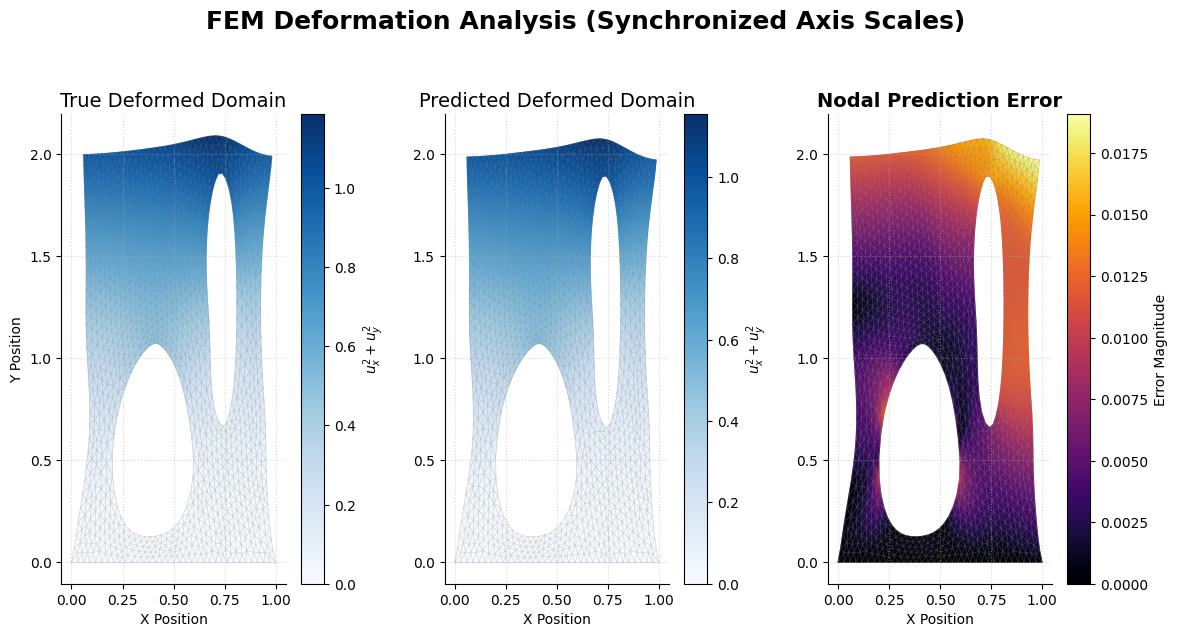

In [159]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.colors import LinearSegmentedColormap

# --- Color Definitions & Custom Colormap ---
COLOR_BLACK = '#000000'
COLOR_GREY  = '#808080'
COLOR_NAVY  = '#000080'
COLOR_ROYAL = '#4169E1'

# Creating a gradient: Black -> Grey -> Navy -> Royal
custom_cmap = LinearSegmentedColormap.from_list("fem_style", 
    [COLOR_BLACK, COLOR_GREY, COLOR_NAVY, COLOR_ROYAL], N=256)

# --- 1. Calculations ---
u_true_sq_mag = u_true[:, 0]**2 + u_true[:, 1]**2
u_pred_sq_mag = u_pred[:, 0]**2 + u_pred[:, 1]**2
u_error_mag = np.linalg.norm(u_true - u_pred, axis=1)

# Deformed nodal positions
wp_true = node_coords[:, :2] + u_true
wp_pred = node_coords[:, :2] + u_pred

# --- SCALE SYNCHRONIZATION ---
# Calculate GLOBAL limits across both True and Predicted deformed sets
all_x = np.concatenate([wp_true[:, 0], wp_pred[:, 0]])
all_y = np.concatenate([wp_true[:, 1], wp_pred[:, 1]])

x_min, x_max = all_x.min(), all_x.max()
y_min, y_max = all_y.min(), all_y.max()

# Add a 5% margin padding to the axes
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05
x_lims = (x_min - x_margin, x_max + x_margin)
y_lims = (y_min - y_margin, y_max + y_margin)

# Create Triangulations
tri_true = tri.Triangulation(wp_true[:, 0], wp_true[:, 1], cells)
tri_pred = tri.Triangulation(wp_pred[:, 0], wp_pred[:, 1], cells)

# --- 2. Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(12, 6), facecolor='white')
fig.suptitle('FEM Deformation Analysis (Synchronized Axis Scales)', fontsize=18, fontweight='bold', y=1.05)

# Plot 1: True Deformed
ax1 = axes[0]
tpc1 = ax1.tripcolor(tri_true, u_true_sq_mag, cmap="Blues", shading='gouraud')
ax1.triplot(tri_true, color=COLOR_GREY, linewidth=0.5, alpha=0.3)
fig.colorbar(tpc1, ax=ax1, label='$u_x^2 + u_y^2$')
ax1.set_title('True Deformed Domain', fontsize=14)

# Plot 2: Predicted Deformed
ax2 = axes[1]
tpc2 = ax2.tripcolor(tri_pred, u_pred_sq_mag, cmap="Blues", shading='gouraud')
ax2.triplot(tri_pred, color=COLOR_GREY, linewidth=0.5, alpha=0.3)
fig.colorbar(tpc2, ax=ax2, label='$u_x^2 + u_y^2$')
ax2.set_title('Predicted Deformed Domain', fontsize=14)

# Plot 3: Absolute Error on Predicted Mesh
ax3 = axes[2]
tpc3 = ax3.tripcolor(tri_pred, u_error_mag, cmap='inferno', shading='gouraud')
ax3.triplot(tri_pred, color=COLOR_GREY, linewidth=0.5, alpha=0.4)
fig.colorbar(tpc3, ax=ax3, label='Error Magnitude')
ax3.set_title('Nodal Prediction Error', fontsize=14, fontweight='bold')

# --- Formatting & Applying Uniform Scale ---
for i, ax in enumerate(axes):
    ax.set_aspect('equal') # Maintain geometric proportions
    ax.set_xlim(x_lims)    # Synchronized X
    ax.set_ylim(y_lims)    # Synchronized Y
    ax.set_xlabel('X Position')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.set_ylabel('Y Position')

plt.tight_layout()
plt.show()

In [163]:
from core.utils import deformation_gradient_element

In [164]:
coords_cells = node_coords[cells]
u_pred_cells = u_pred[cells]
u_true_cells = u_true[cells]

In [165]:
f_pred, _ = deformation_gradient_element(coords_cells, u_pred_cells)
f_true, _ = deformation_gradient_element(coords_cells, u_true_cells)

In [166]:
f_pred

Array([[[ 0.92009, -0.03012],
        [ 0.02617,  1.66563]],

       [[ 0.9199 , -0.03031],
        [ 0.02714,  1.6666 ]],

       [[ 0.9201 , -0.03013],
        [ 0.03615,  1.66198]],

       [[ 0.9234 , -0.03987],
        [ 0.02679,  1.66754]],

       [[ 0.91568, -0.03283],
        [ 0.04156,  1.66528]],

       [[ 0.91916, -0.04096],
        [ 0.03687,  1.67012]],

       [[ 0.92079, -0.04426],
        [ 0.03034,  1.6735 ]],

       [[ 0.91791, -0.03426],
        [ 0.04768,  1.66134]],

       [[ 0.92021, -0.04171],
        [ 0.04229,  1.66627]],

       [[ 0.92272, -0.04843],
        [ 0.02993,  1.67437]],

       [[ 0.91306, -0.03692],
        [ 0.05435,  1.66499]],

       [[ 0.91774, -0.04298],
        [ 0.04783,  1.66913]],

       [[ 0.92084, -0.04811],
        [ 0.04169,  1.67231]],

       [[ 0.92145, -0.05036],
        [ 0.03235,  1.67806]],

       [[ 0.92074, -0.04822],
        [ 0.04239,  1.67305]],

       [[ 0.91691, -0.03952],
        [ 0.06009,  1.6611 ]],

       [

In [167]:
def _dev_input(invariants) :
    i3 = jnp.maximum(invariants[2], 1e-6)
    i1_dev = i3**(-1/3)*invariants[0]
    i2_dev = i3**(-2/3)*invariants[1]
    return jnp.stack([i1_dev, i2_dev, i3], axis = -1)

In [168]:
invariant_func = jax.vmap(invariants_and_derivatives)
i_pred, _ = invariant_func(f_pred)
i_true, _ = invariant_func(f_true)
vec_dev_input = jax.vmap(_dev_input)
i_pred_dev = vec_dev_input(i_pred)
i_true_dev = vec_dev_input(i_true)


<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_24278/2554034789.py:11: SyntaxWarning: invalid escape sequence '\o'
  labels = ['$I_1 = \operatorname{tr}{C}$',
/tmp/ipykernel_24278/2554034789.py:13: SyntaxWarning: invalid escape sequence '\o'
  '$I_3 = \operatorname{det}(C)$']


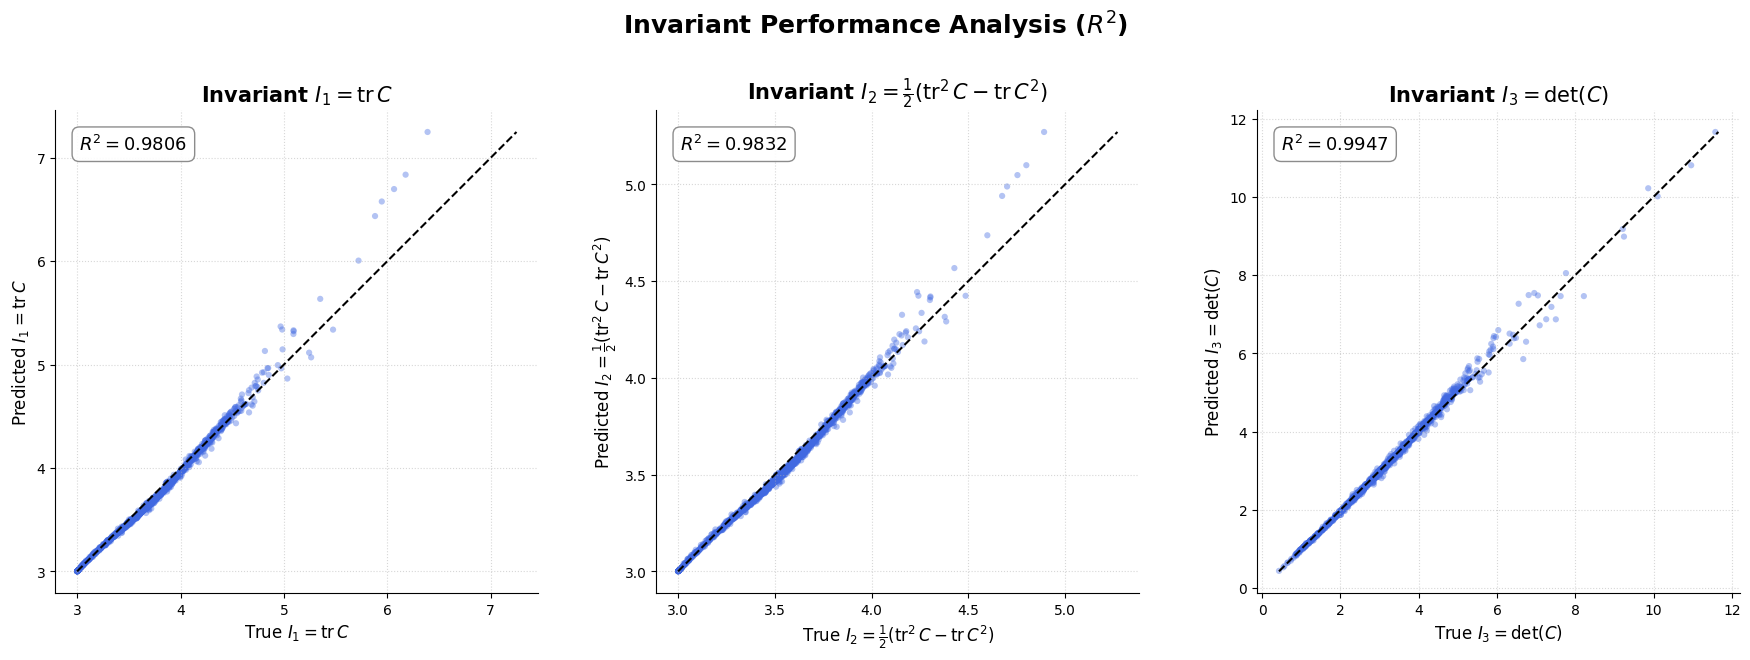

In [172]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# --- Color Palette ---
COLOR_BLACK = '#000000'
COLOR_ROYAL = '#4169E1'
COLOR_GREY  = '#808080'

# Assuming true_invariant and pred_invariant are (#data, 3) arrays
labels = ['$I_1 = \operatorname{tr}{C}$', 
          r'$I_2 = \frac{1}{2} (\operatorname{tr}^2{C} - \operatorname{tr}{C^2})$', 
          '$I_3 = \operatorname{det}(C)$']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
fig.suptitle('Invariant Performance Analysis ($R^2$)', fontsize=18, fontweight='bold', y=1.05)

for i in range(3):
    ax = axes[i]
    y_true = i_true_dev[:, i]
    y_pred = i_pred_dev[:, i]
    
    # Calculate R2 score
    score = r2_score(y_true, y_pred)
    
    # Scatter Plot (Royal Blue points with transparency for density)
    ax.scatter(y_true, y_pred, color=COLOR_ROYAL, alpha=0.4, s=20, edgecolors='none')
    
    # Identity Line (y=x) in Black
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color=COLOR_BLACK, linestyle='--', linewidth=1.5, label='Ideal')
    
    # Formatting
    ax.set_title(f'Invariant {labels[i]}', fontsize=15, fontweight='bold')
    ax.set_xlabel(f'True {labels[i]}', fontsize=12)
    ax.set_ylabel(f'Predicted {labels[i]}', fontsize=12)
    
    # Display R2 Score in a box
    ax.text(0.05, 0.95, f'$R^2 = {score:.4f}$', transform=ax.transAxes, 
            fontsize=13, fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor=COLOR_GREY))
    
    # Styling
    ax.set_aspect('equal') # Important for parity plots to keep the slope visually correct
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()